# Simulating Lattices using PBC and OBC

In this section, you will learn how to simulate both **Periodic Boundary Conditions (PBC)** and **Open Boundary Conditions (OBC)** using MoirePy. Understanding the transition between these two is vital for distinguishing between bulk properties and edge-specific phenomena.

## 1. Physical Difference: Bulk vs. Flake

* **PBC (`pbc=True`)**: Represents an **infinite periodic system**. Atoms at the boundary "wrap around" to connect with atoms on the opposite side of the moiré unit cell, simulating an endless bulk material.
* **OBC (`pbc=False`)**: Represents a **finite flake or nanostructure**. Atoms at the boundaries have fewer neighbors because the lattice physically ends, creating edges.

## 2. Minimal Setup

We define the same lattice geometry once, toggling only the `pbc` flag to see how it changes the connectivity.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from moirepy import BilayerMoireLattice, HexagonalLayer

In [ ]:
# Parameters for around ~9.43 degree twist
params = {
    "latticetype": HexagonalLayer,
    "ll1": 3, "ll2": 4, "ul1": 4, "ul2": 3,
    "n1": 1, "n2": 1
}

In [12]:
# 1. Open Boundary Conditions
lattice_obc = BilayerMoireLattice(**params, pbc=False)

twist angle = 0.1646 rad (9.4300 deg)
74 cells in upper lattice
74 cells in lower lattice


In [13]:
# 2. Periodic Boundary Conditions
lattice_pbc = BilayerMoireLattice(**params, pbc=True)

twist angle = 0.1646 rad (9.4300 deg)
74 cells in upper lattice
74 cells in lower lattice


## 3. Hamiltonian and Connectivity

The internal logic for finding neighbors changes significantly. In PBC, MoirePy uses a **KDTree** on a set of "ghost" atoms (bigger lattice) to ensure that atoms near the edge find their counterparts on the other side.

In [14]:
lattice_obc.generate_connections(inter_layer_radius=1)
lattice_pbc.generate_connections(inter_layer_radius=1)

# Generate Hamiltonians with identical hopping parameters
ham_obc = lattice_obc.generate_hamiltonian(tll=1, tuu=1, tul=0.8, tlu=0.8)
ham_pbc = lattice_pbc.generate_hamiltonian(tll=1, tuu=1, tul=0.8, tlu=0.8)

print(f"OBC Non-zero entries: {ham_obc.nnz}")
print(f"PBC Non-zero entries: {ham_pbc.nnz}")

OBC Non-zero entries: 1460
PBC Non-zero entries: 1670


!!! info Automatic Neighbor Wrapping
    In **PBC**, an atom at the far right edge connects to a neighbor at the far left edge. MoirePy handles this mapping automatically. You don't need to manually calculate wrapped coordinates. This results in a higher number of non-zero entries (`nnz`) in the PBC Hamiltonian.

- Converting sparse matrices to dense because system size is small anyway and it is easier to work with dense matrices
- We have added only real hopping parameters, so real space hamiltonian would be purely real and imaginary parts are zero. Hence keeping only the real part is sufficient

In [15]:
ham_obc = ham_obc.toarray().real
ham_pbc = ham_pbc.toarray().real

## 4. Visual Comparison (Hamiltonian Structure)

Let's plot the hamiltonian matrices and let's see how they look like:

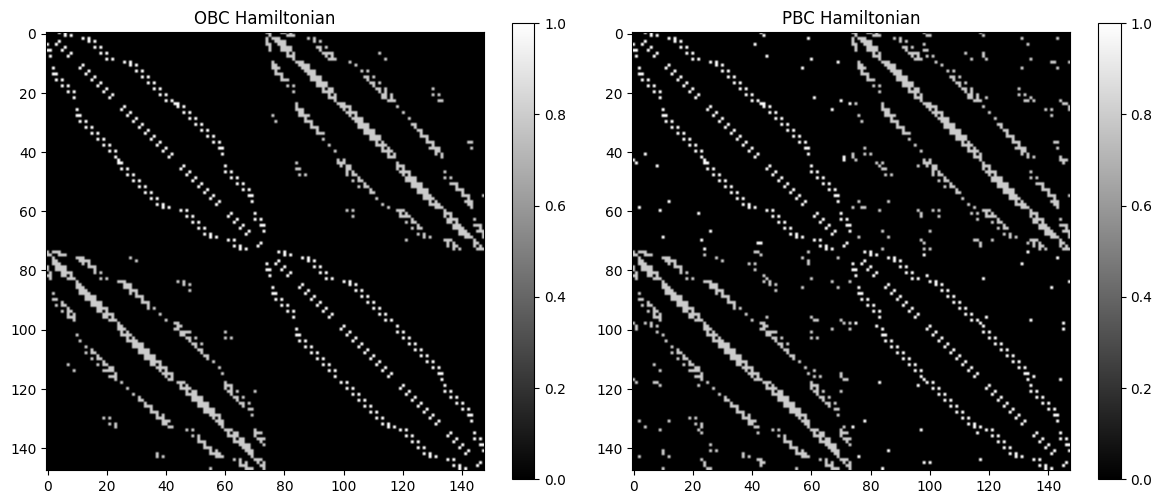

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# OBC plot
im0 = axes[0].imshow(ham_obc, cmap="gray")
axes[0].set_title("OBC Hamiltonian")
fig.colorbar(im0, ax=axes[0])

# PBC plot
im1 = axes[1].imshow(ham_pbc, cmap="gray")
axes[1].set_title("PBC Hamiltonian")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()

## 5. Spectrum Comparison

The choice of boundary conditions significantly affects the energy eigenvalues. For example in a toplogically non trivial system [1] OBC introduces "edge states" that may appear in gaps where the bulk (PBC) system has no states.

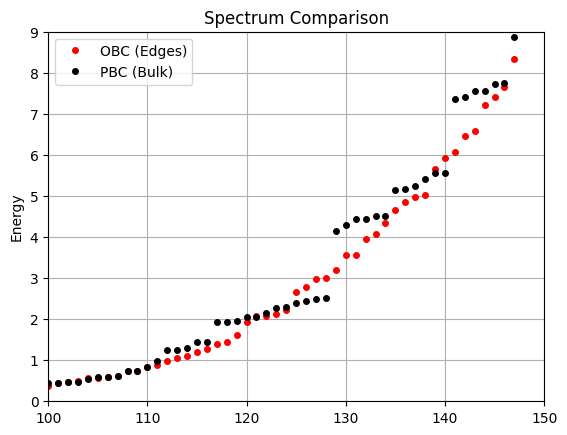

In [17]:
def get_spectrum(ham):
    vals = np.linalg.eigvalsh(ham)
    return np.sort(vals)

spec_obc = get_spectrum(ham_obc)
spec_pbc = get_spectrum(ham_pbc)

plt.plot(spec_obc, 'ro', label='OBC (Edges)', markersize=4)
plt.plot(spec_pbc, 'ko', label='PBC (Bulk)', markersize=4)
plt.xlim(100, 150)
plt.ylim(0, 9)
plt.legend()
plt.ylabel("Energy")
plt.title("Spectrum Comparison")
plt.grid(True)

## What We Did

* Constructed the same lattice with OBC and PBC  
* Observed how connectivity changes at the boundaries  
* Compared Hamiltonians and resulting spectra  

This demonstrates how boundary conditions control whether you simulate a finite system or an infinite periodic system.

## Next Steps

1. **[K-Space & Band Structures](k_space_hamiltonian.md)**: Work in momentum space for periodic systems.  
2. **[Defining Custom Layers](prepare_layers.md)**: Build your own lattice geometries.  
3. **[Designing Custom Hopping](custom_hoppings.md)**: Add realistic physics.  
4. **[Tutorials and Replicated Papers](../examples.md)**: See full physical results.  
